# HSSM in thirty minutes

**Day 3, 09:30 — 30 minutes.** Alexander Fengler.

<img src="../../images/logos/hssm-logo.png" alt="HSSM logo"
     style="display:block; margin:0.5rem auto 1.5rem auto; width:240px">

Yesterday at 12:00 you saw **bambi**: write `"y ~ 1 + x"`, and it builds the
PyMC model, chooses priors, fits, and predicts at new covariates. At 14:30
you dropped a DDM likelihood into PyMC by hand and wrote `v[coh_idx]` to make
drift depend on condition.

**HSSM is what you get when you combine those two ideas.** It is a formula
interface — built on bambi — for models whose likelihood is a
sequential-sampling model rather than a Gaussian. The extra axes of
flexibility it adds over bambi are:

| | bambi | HSSM |
|---|---|---|
| likelihood | GLM families | **DDM, LBA, race, collapsing-bound, …** |
| what a formula acts on | parameters of the family | **translates to any SSM parameter** — drift, boundary, bias, non-decision time |
| where the likelihood comes from | closed form | closed form, a **neural approximation**, or your own function |
| extras features | — | native lapse processes, proprietary plots, "surrogate -> PyMC RV" constructors |


<details class="sbi-note">
<summary>▶️ <b>Running this on Google Colab</b></summary>

The cell below is a no-op on your own machine. On Colab it installs the stack
and downloads the shared helper module, which lives one directory up in the
repository and is therefore not importable there.

Expect the install to take a few minutes. If Colab asks you to restart the
runtime, do it and then run the cell again — the second run is a no-op.

</details>

In [1]:
# --- Google Colab bootstrap; does nothing anywhere else ---------------------
import importlib.util, pathlib, subprocess, sys, urllib.error, urllib.request

IN_COLAB = importlib.util.find_spec("google.colab") is not None

# `main` once this is merged; the branch is the fallback so the Colab path can
# be tested BEFORE the merge, when main does not yet have these files.
_REFS = ("main", "af-day3-final-cleanup")
_RAW = "https://raw.githubusercontent.com/stefanradev93/sbi4cogsci/{ref}/tutorials/"


def _fetch(path, dest=None):
    """Download `path` (relative to `tutorials/`) to `dest`, default its basename."""
    dest = dest or path.rsplit("/", 1)[-1]
    for ref in _REFS:
        try:
            urllib.request.urlretrieve(_RAW.format(ref=ref) + path, dest)
            return ref
        except urllib.error.HTTPError:
            continue
    raise RuntimeError(f"could not fetch {path} from any of {_REFS}")


if IN_COLAB:
    # numba>=0.61 is REQUIRED, not cosmetic. pytensor resolves linker="auto" to
    # its numba backend, and numba renamed FunctionModel's first field
    # addr -> c_addr in 0.61. Colab preinstalls an older numba, and pytensor
    # declares numba only as an optional extra, so pip leaves it in place and
    # any MvNormal (SolveTriangular has no C implementation) dies with
    # KeyError: "FunctionModel does not have a field named 'c_addr'".
    # bayesflow pulls keras 3, which section 7 needs — without it the notebook
    # dies at `import bayesflow` rather than anywhere informative.
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "numba>=0.61", "pymc>=6.2", "arviz>=1.2", "hssm>=0.4",
                    "bayesflow>=2.0"],
                   check=True)
    # `dot` is a system binary, not a Python package.
    subprocess.run(["apt-get", "-qq", "install", "-y", "graphviz"],
                   check=True)
    for _mod in ["sbi4cogsci_style.py"]:
        print(f"  fetched {_mod} from {_fetch(_mod)}")
    # Section 7 LOADS a trained network rather than training one. Skip this and
    # `CKPT.exists()` is False on Colab, so that cell silently drops into its
    # training branch — 150 epochs x 300 batches, roughly 25 minutes.
    pathlib.Path("checkpoints").mkdir(exist_ok=True)
    _ck = "day3_sbi_tools/checkpoints/ddm_nre.keras"
    print(f"  fetched ddm_nre.keras from "
          f"{_fetch(_ck, 'checkpoints/ddm_nre.keras')}")
    print("Colab setup done.")

In [2]:
import sys, pathlib, warnings
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # -> tutorials/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
import hssm
import sbi4cogsci_style as S

S.use()
warnings.filterwarnings("ignore")

RANDOM_SEED = sum(map(ord, "sbi4cogsci-hssm"))
rng = np.random.default_rng(RANDOM_SEED)
PARAMS = ["v", "a", "z", "t"]

print("hssm", hssm.__version__, "|", len(hssm.list_models()), "built-in models")

hssm 0.4.0 | 16 built-in models


## 1. A dataset whose truth we know

We could load a real dataset. Instead we **build one from a known model**, so
that every claim about recovery later is checkable rather than rhetorical.

The design is modelled on `cavanagh_theta`, the classic dataset shipped with
HSSM: participants, a trial-level covariate, and a condition.

The generative model is

$$
v_i = \beta^v_0 + \beta^v_1\, \mathbb{1}[\text{cond}_i = \text{"hard"}],
\qquad
a_i = \beta^a_0 + \beta^a_1\, \text{theta}_i,
$$

with $z$ and $t$ fixed. **Difficulty acts on the drift** — a harder stimulus
supplies weaker evidence — and **theta acts on the boundary**.

That assignment is a modelling claim, not a convenience. It matches what
`cavanagh_theta` is famous for — mediofrontal theta tracks the **decision
threshold**, not the rate of evidence accumulation — and it makes the two
manipulations *visibly different*: drift moves accuracy and RT together,
boundary trades them off. The exercise at the end asks what happens if you
swap them.

In [3]:
N_TRIALS = 1200
theta_cov = rng.normal(0.0, 1.0, N_TRIALS)               # trial-level covariate
cond = rng.choice(["easy", "hard"], N_TRIALS)

scaffold = hssm.simulate_data("ddm", [0.5, 1.5, 0.5, 0.3], N_TRIALS,
                              random_state=RANDOM_SEED)
scaffold["theta"] = theta_cov
scaffold["cond"] = cond

# The generating model. p_outlier=None so the synthetic data contains no
# lapses; center_predictors=False so an Intercept means "the value at 0".
gen_model = hssm.HSSM(
    data=scaffold, model="ddm",
    include=[{"name": "v", "formula": "v ~ 1 + C(cond)"},
             {"name": "a", "formula": "a ~ 1 + theta"}],
    p_outlier=None, center_predictors=False,
)

# Every free parameter must be pinned, and each value must match that
# parameter's SHAPE. Categorical contrasts are vectors even when there is only
# one of them — `v_C(cond)` has shape (1,), so it takes [-0.4], not -0.4.
#
# The two drift values are chosen to land both conditions in the 15-35% error
# band that yesterday afternoon identified as the well-conditioned regime:
# easy ends up near 14% errors, hard near 36%.
TRUE = {
    "v_Intercept": 0.6,      # drift in the "easy" condition
    "v_C(cond)": [-0.4],     # how much WEAKER the evidence is when "hard"
    "a_Intercept": 1.5,      # boundary at theta = 0
    "a_theta": 0.3,          # boundary per unit of theta
    "z": 0.5,
    "t": 0.30,
}
print("free parameters and their shapes:")
for rv, val in gen_model.pymc_model.initial_point().items():
    print(f"   {rv:24s} {val.shape}")

# `sample_do` pins every free parameter to a chosen value and draws from the
# resulting model — the do-operator you met yesterday, used generatively.
dt = gen_model.sample_do(TRUE, draws=1, random_seed=RANDOM_SEED)
sim = dt["prior_predictive"]["rt,response"].values[0, 0]     # (N_TRIALS, 2)

data = pd.DataFrame(sim, columns=["rt", "response"])
data["theta"] = theta_cov
data["cond"] = cond
data["participant_id"] = rng.integers(0, 12, N_TRIALS)       # for section 6

print(data.head().to_string(index=False))
print(f"\n{len(data)} trials | error rate {(data['response'] == -1).mean():.1%}")

Model initialized successfully.


Sampling: [rt,response]


free parameters and their shapes:
   z_interval__             ()
   t_log__                  ()
   v_Intercept              ()
   v_C(cond)                (1,)
   a_Intercept_interval__   ()
   a_theta                  ()


      rt  response     theta cond  participant_id
2.453736       1.0  1.293487 hard               4
1.036704       1.0 -0.930231 hard              11
2.971241       1.0 -0.313631 easy              10
2.307350       1.0  0.472591 easy              10
9.768160       1.0  0.424181 hard               0

1200 trials | error rate 25.2%


<details class="sbi-key" open>
<summary>🔑 <b>Response coding in HSSM</b></summary>

Two-choice models expect responses coded `-1` and `+1`. You never have to
guess this — every model declares it:

```python
hssm.config.model_config["ddm"]["choices"]   ->  [-1, 1]
```

Multi-alternative models use `[0 … K-1]` instead, and declare that the same
way. Check the config rather than assuming.

</details>

In [4]:
from ssms.config import model_config
for name in ["ddm", "angle", "lba3", "race_no_bias_angle_4"]:
    print(f"  {name:22s} choices = {model_config[name]['choices']}")

  ddm                    choices = [-1, 1]
  angle                  choices = [-1, 1]
  lba3                   choices = [0, 1, 2]
  race_no_bias_angle_4   choices = [0, 1, 2, 3]


## 2. The shortest model that works

One line for the model, one for the fit.

In [5]:
model_flat = hssm.HSSM(data=data, model="ddm")
print(model_flat)

Model initialized successfully.


Hierarchical Sequential Sampling Model
Model: ddm

Response variable: rt,response
Likelihood: analytical
Observations: 1200

Parameters:

v:
    Prior: Normal(mu: 0.0, sigma: 2.0)
    Explicit bounds: (-inf, inf)

a:
    Prior: HalfNormal(sigma: 2.0)
    Explicit bounds: (0.0, inf)

z:
    Prior: Uniform(lower: 0.0, upper: 1.0)
    Explicit bounds: (0.0, 1.0)

t:
    Prior: HalfNormal(sigma: 2.0)
    Explicit bounds: (0.0, inf)


Lapse probability: 0.05
Lapse distribution: Uniform(lower: 0.0, upper: 20.0)


`print(model)` resolves and shows every prior, every bound, the links, and the
lapse process. Read it before sampling, every time.

The graph shows the same thing structurally:

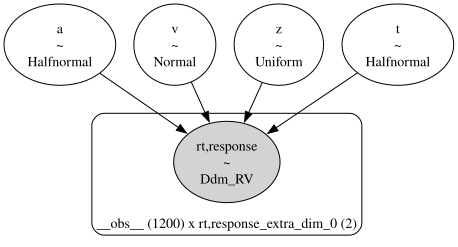

In [6]:
model_flat.graph()

In [7]:
model_flat.sample(draws=500, tune=500, chains=2, cores=1,
                  random_seed=RANDOM_SEED, progressbar=False)
print(az.summary(model_flat.traces, var_names=PARAMS, kind="stats").to_string())

Using default initvals. 



Initializing NUTS using adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [a, t, z, v]


Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 7 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


   mean     sd eti89_lb eti89_ub
v   0.4  0.028     0.35     0.44
a   1.5  0.024      1.4      1.5
z  0.49  0.011     0.47     0.51
t  0.23   0.02      0.2     0.26


## 3. `p_outlier`: the lapse process

Notice the last line of `print(model)`: **`Lapse probability: 0.05`**. Every
HSSM model carries one unless you say otherwise, and it is worth
understanding rather than merely knowing about.

Real response-time data contains trials the model did not generate — button
mashing, attention lapses, a sneeze. Those trials have RTs the SSM considers
nearly impossible, and because the likelihood is a *product* over trials, one
impossible trial can dominate the entire fit.

HSSM's answer is a mixture. With lapse probability $p$ and lapse density
$f_{\text{lapse}}$,

$$
f_{\text{eff}}(\text{rt}) \;=\; (1-p)\, f_{\text{SSM}}(\text{rt}) \;+\; p\, f_{\text{lapse}}(\text{rt}),
$$

with $f_{\text{lapse}}$ defaulting to $\text{Uniform}(0, 20)$. The effect is a
**floor**: no observation can ever be more surprising than $\log(p/20)$.

In [8]:
import pymc as pm

probe = pd.DataFrame({"rt": [0.9, 0.31, 18.0], "response": [1.0, 1.0, -1.0]})
THETA = dict(v=2.0, a=2.5, z=0.5, t=0.3)

m_on = hssm.HSSM(data=probe, model="ddm", p_outlier=0.05, a=2.5, z=0.5, t=0.3)
m_off = hssm.HSSM(data=probe, model="ddm", p_outlier=None, a=2.5, z=0.5, t=0.3)

obs = probe[["rt", "response"]].to_numpy()
lp_off = pm.logp(m_off.model_distribution.dist(**THETA), obs).eval()
lp_on = pm.logp(m_on.model_distribution.dist(**THETA, p_outlier=0.05), obs).eval()

print(f"{'rt':>7} {'no lapse':>12} {'with lapse':>12}")
for r, off, on in zip(probe["rt"], lp_off, lp_on):
    print(f"{r:7.2f} {off:12.2f} {on:12.2f}")
print(f"\nthe floor is log(p/20) = {np.log(0.05 / 20):.3f}")

Model initialized successfully.


Model initialized successfully.


     rt     no lapse   with lapse
   0.90        -0.64        -0.69
   0.31       -64.34        -5.99
  18.00       -45.97        -5.99

the floor is log(p/20) = -5.991


The typical trial barely moves. The impossibly fast one (`rt` below the
non-decision time, so the SSM says it *cannot happen*) goes from $-64$ to the
floor, and the very slow one likewise. Draw it:

Model initialized successfully.


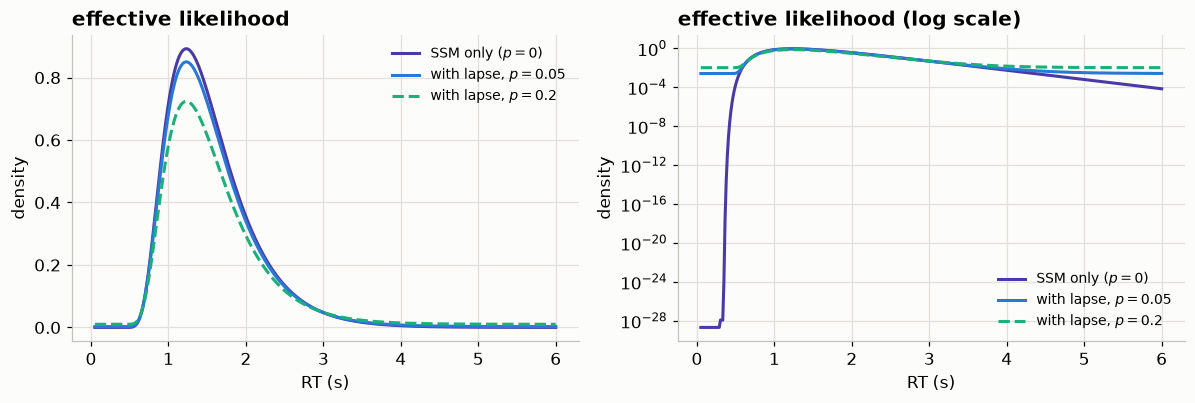

In [9]:
rt_grid = np.linspace(0.05, 6.0, 400)
grid_df = pd.DataFrame({"rt": rt_grid, "response": np.ones_like(rt_grid)})
m_g_off = hssm.HSSM(data=grid_df, model="ddm", p_outlier=None, a=2.5, z=0.5, t=0.3)
dens_ssm = np.exp(pm.logp(m_g_off.model_distribution.dist(**THETA),
                          grid_df[["rt", "response"]].to_numpy()).eval())

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, logscale in zip(axes, [False, True]):
    ax.plot(rt_grid, dens_ssm, color=S.NAIVE, lw=2, label="SSM only ($p=0$)")
    for p, colour, ls in [(0.05, S.PRIMARY, "-"), (0.20, S.ALT, "--")]:
        ax.plot(rt_grid, (1 - p) * dens_ssm + p * (1 / 20),
                color=colour, ls=ls, lw=2, label=f"with lapse, $p={p}$")
    ax.set(xlabel="RT (s)", ylabel="density",
           title="effective likelihood" + (" (log scale)" if logscale else ""))
    if logscale:
        ax.set_yscale("log")
    ax.legend(fontsize=9)
fig.tight_layout()

On the linear scale the mixture is indistinguishable from the SSM density —
that is the point, it barely touches the trials the model explains well. On
the **log** scale you can see what it actually does: it holds the density up
off zero everywhere, so no single trial can contribute an unboundedly large
negative log-likelihood.

## 4. Fit checks that are specific to SSMs

A trace plot tells you the sampler behaved. It says nothing about whether the
model describes the data.

The **quantile probability plot** is the field standard: RT quantiles on the
y-axis against choice proportion on the x-axis, so speed and accuracy appear
together, split by condition. Ellipses summarise the posterior-predictive
spread more legibly than a point cloud.

dt=None, we use the traces assigned to the HSSM object as datatree.


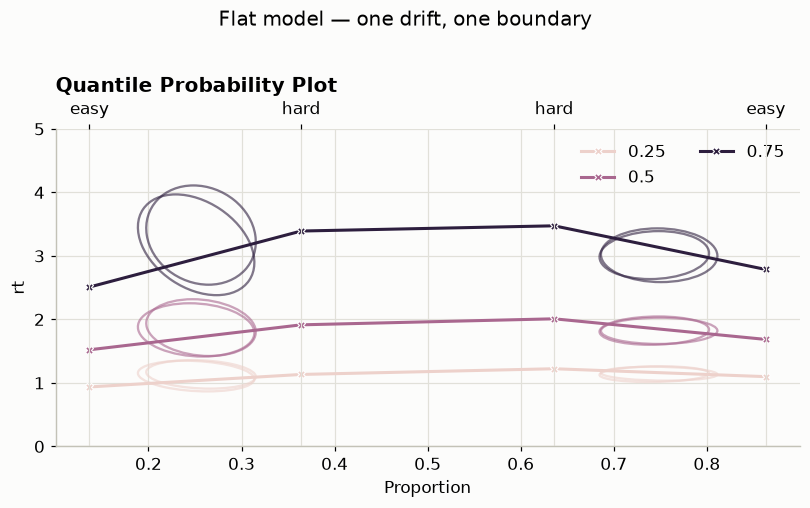

In [10]:
model_flat.sample_posterior_predictive(kind="response", draws=100)
ax = model_flat.plot_quantile_probability(cond="cond", predictive_style="ellipse",
                                          ellipse_confidence=0.95)
# The method returns its Axes, so the y-limits are yours to set. Do set them:
# the default view clips to the observed quantiles, which slices the tops off
# the predictive ellipses and hides exactly the misfit you are looking for.
ax.set_ylim(0, 5)
plt.gcf().set_size_inches(7.5, 4.5)
plt.gcf().suptitle("Flat model — one drift, one boundary", y=1.02)
plt.tight_layout()

The **model cartoon** draws the fitted process itself: boundaries, start
point, drift and non-decision time, with the observed RT histograms mirrored
above and below.

Two arguments make it show *uncertainty* rather than a single tidy summary.
`plot_predictive_samples=True` draws one boundary-and-drift sketch per
posterior draw, so the grey fan is the posterior on the parameters;
`n_trajectories` overlays actual simulated paths. The mean drift is not what
any single trial does.

No posterior_predictive samples found. Generating posterior_predictive samples using the provided DataTree object and the original data. This will modify the provided DataTree object, or if not provided, the traces object stored inside the model.


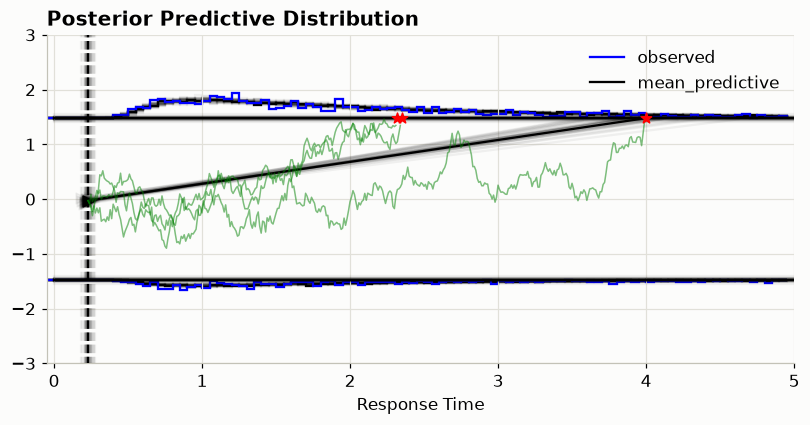

In [11]:
hssm.plotting.plot_model_cartoon(model_flat, n_samples=20,
                                 plot_predictive_samples=True,
                                 n_trajectories=3)
plt.gcf().set_size_inches(7.5, 4)
plt.tight_layout()

## 5. A more accurate model

The flat model has one drift and one boundary for every trial, but we built
this dataset so that drift depends on `cond` and boundary tracks `theta`.
In HSSM that is a formula per parameter — the bambi idea, applied to the
inside of a cognitive model.

Model initialized successfully.


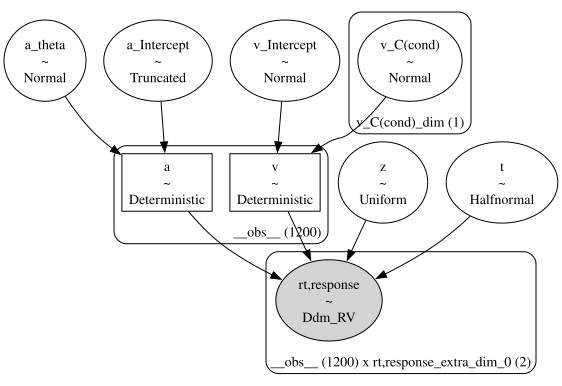

In [12]:
model_reg = hssm.HSSM(
    data=data, model="ddm",
    include=[{"name": "v", "formula": "v ~ 1 + C(cond)"},
             {"name": "a", "formula": "a ~ 1 + theta"}],
    p_outlier=0.05,
)
model_reg.graph()

In [13]:
model_reg.sample(draws=500, tune=500, chains=2, cores=1,
                 random_seed=RANDOM_SEED, progressbar=False)
print(az.summary(model_reg.traces,
                 var_names=["v_Intercept", "v_C(cond)", "a_Intercept",
                            "a_theta", "z", "t"],
                 kind="stats").to_string())
print("\nTRUE:", {k: v for k, v in TRUE.items()})

Using default initvals. 



Initializing NUTS using adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [t, z, v_Intercept, v_C(cond), a_Intercept, a_theta]


Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 9 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


                  mean     sd eti89_lb eti89_ub
v_Intercept       0.67  0.039      0.6     0.73
v_C(cond)[hard]  -0.44  0.045    -0.52    -0.37
a_Intercept        1.5  0.023      1.5      1.5
a_theta           0.27  0.017     0.24     0.29
z                 0.49  0.011     0.47     0.51
t                  0.3  0.015     0.27     0.32

TRUE: {'v_Intercept': 0.6, 'v_C(cond)': [-0.4], 'a_Intercept': 1.5, 'a_theta': 0.3, 'z': 0.5, 't': 0.3}


dt=None, we use the traces assigned to the HSSM object as datatree.


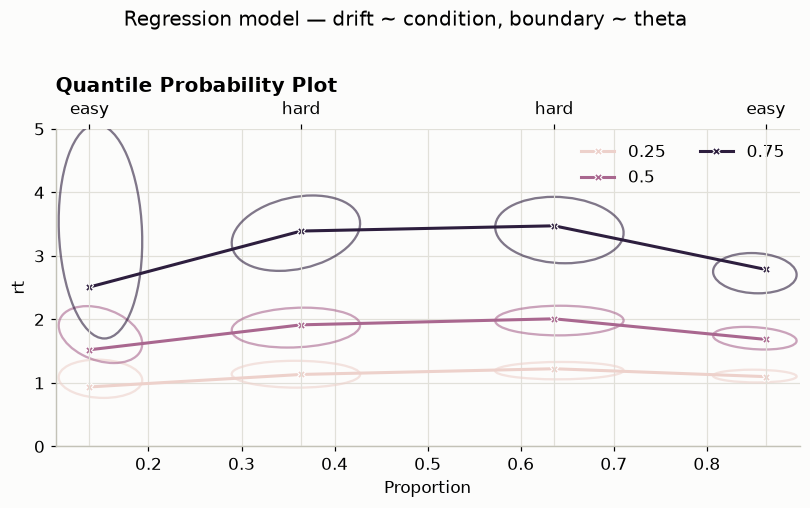

In [14]:
model_reg.sample_posterior_predictive(kind="response", draws=100)
ax = model_reg.plot_quantile_probability(cond="cond", predictive_style="ellipse",
                                         ellipse_confidence=0.95)
ax.set_ylim(0, 5)          # same y-range as the flat model, so the two compare
plt.gcf().set_size_inches(7.5, 4.5)
plt.gcf().suptitle("Regression model — drift ~ condition, boundary ~ theta", y=1.02)
plt.tight_layout()

### How to read a quantile probability plot

The standard fit check for sequential-sampling models, and worth learning to
read properly because it shows accuracy and RT *at the same time*.

- **Horizontal axis** — the proportion of responses in that group. Each
  condition contributes **two** points: errors on the left, correct responses
  on the right, mirrored about 0.5.
- **Vertical axis** — the 25th, 50th and 75th RT percentiles, so the vertical
  spread *is* the shape of the RT distribution.
- **Ellipses** — the posterior predictive. The model fits where they cover the
  observed points.

The four x-positions read outward from the centre as: hard errors, hard
correct, easy errors, easy correct. Compare it with the flat model above,
which collapses both conditions onto a single pair of positions — a single
drift cannot produce two accuracies.

<details class="sbi-tip">
<summary>💡 <b>This is the key argument for HSSM</b></summary>

`include=[{"name": "v", "formula": "v ~ 1 + C(cond)"}]` replaced the
`v[coh_idx]` indexing you wrote by hand yesterday — and it extends to random
effects, multiple parameters, and link functions without you writing any of
it.

</details>

### Exercise

Fit a model where the mapping is **swapped**: drift depends on `theta` and
boundary on `cond`. It has exactly the same number of parameters. Compare its
quantile probability plot to the one above, and predict first — which of the
two axes of the plot will it get wrong?

<details>
<summary>What to notice</summary>

```python
swapped = hssm.HSSM(
    data=data, model="ddm",
    include=[{"name": "v", "formula": "v ~ 1 + theta"},
             {"name": "a", "formula": "a ~ 1 + C(cond)"}])
swapped.sample(draws=500, tune=500, chains=2, cores=1, progressbar=False)
swapped.sample_posterior_predictive(kind="response", draws=100)
swapped.plot_quantile_probability(cond="cond", predictive_style="ellipse")
```

The **horizontal** axis is the one that collapses. Boundary height barely
moves accuracy when the start point is unbiased — raising `a` makes both
responses slower and leaves their *ratio* almost untouched — so a model that
puts the condition effect on `a` predicts the two conditions at nearly the
same proportion. Its predicted ellipses stack up in two vertical columns while
the observed points sit at four clearly separated positions.

It still fits far better than the flat model, and it has the right number of
parameters. That is the trap: **the right number of parameters is not the same
as the right model**, and a summary table of coefficients will not tell you —
the fit check will.

This is also a design lesson, not only a modelling one. If your manipulation
only ever moves the boundary, a quantile probability plot has almost no
horizontal spread to check against, and you have thrown away the axis that
makes the model falsifiable.

</details>

## 6. Hierarchical regression

Real designs have participants. HSSM takes bambi's random-effects syntax
directly, so a participant-level drift intercept is `(1|participant_id)`.

Model initialized successfully.


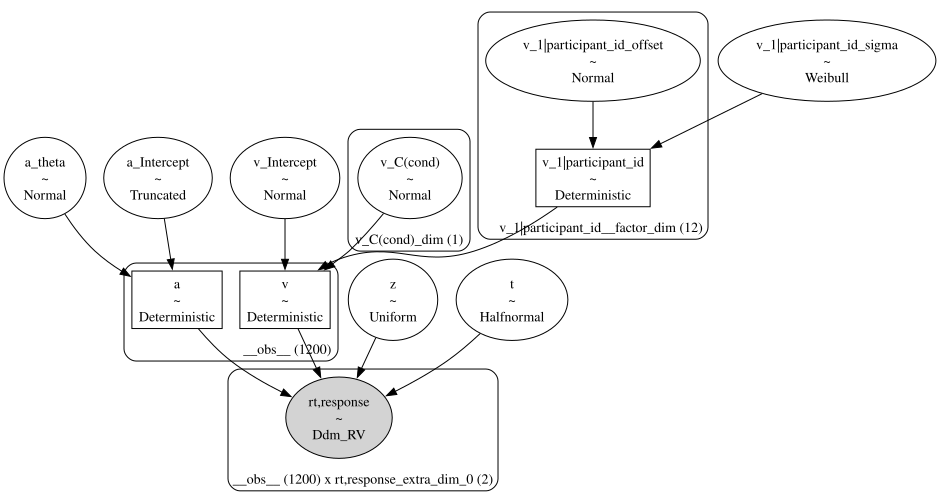

In [15]:
model_hier = hssm.HSSM(
    data=data, model="ddm",
    include=[{"name": "v", "formula": "v ~ 1 + C(cond) + (1|participant_id)"},
             {"name": "a", "formula": "a ~ 1 + theta"}],
    noncentered=True,          # see Day 3, 11:00 for why this matters
    p_outlier=0.05,
    prior_settings="safe",
)
model_hier.graph()

In [16]:
model_hier.sample(draws=500, tune=500, chains=2, cores=1,
                  random_seed=RANDOM_SEED, progressbar=False)
print(az.summary(model_hier.traces,
                 var_names=["v_Intercept", "v_C(cond)", "v_1|participant_id_sigma",
                            "a_Intercept", "a_theta"],
                 kind="stats").to_string())

Using default initvals. 



Initializing NUTS using adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [t, z, v_Intercept, v_C(cond), v_1|participant_id_sigma, v_1|participant_id_offset, a_Intercept, a_theta]


Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 33 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


                           mean     sd eti89_lb eti89_ub
v_Intercept                0.67   0.04      0.6     0.73
v_C(cond)[hard]           -0.44  0.046    -0.52    -0.37
v_1|participant_id_sigma   0.04  0.024   0.0081    0.084
a_Intercept                 1.5  0.023      1.5      1.5
a_theta                    0.27  0.017     0.24     0.29


`v_1|participant_id_sigma` is the **population spread** of participant drift
intercepts. Our synthetic participants were assigned at random, so it should
be near zero — and a hierarchical model that correctly reports "there is no
participant variance here" is doing its job.

The geometry of that `sigma` parameter is what the 11:00 session is about.

A **forest plot** is the natural summary for a hierarchical fit: every
coefficient on one axis, with intervals you can scan for overlap with zero.

One filter first. A fitted posterior can hold two kinds of variable: a handful
of **coefficients**, and — depending on the model — deterministics carrying
*one entry per trial*. Hand the second kind to `plot_forest` and it will
dutifully draw thousands of rows. Select on the dimensions, not by listing
names that go stale the moment you edit a formula:

In [17]:
post = model_hier.traces.posterior
n_obs = len(data)

coef_vars = [
    v for v in post.data_vars
    # keep anything with no trial-sized axis
    if not any(post[v].sizes[d] == n_obs for d in post[v].dims)
]
print(f"{len(post.data_vars)} posterior variables -> {len(coef_vars)} coefficients")
print("dropped:", sorted(set(post.data_vars) - set(coef_vars)) or "nothing (this model stores only coefficients)")

9 posterior variables -> 9 coefficients
dropped: nothing (this model stores only coefficients)


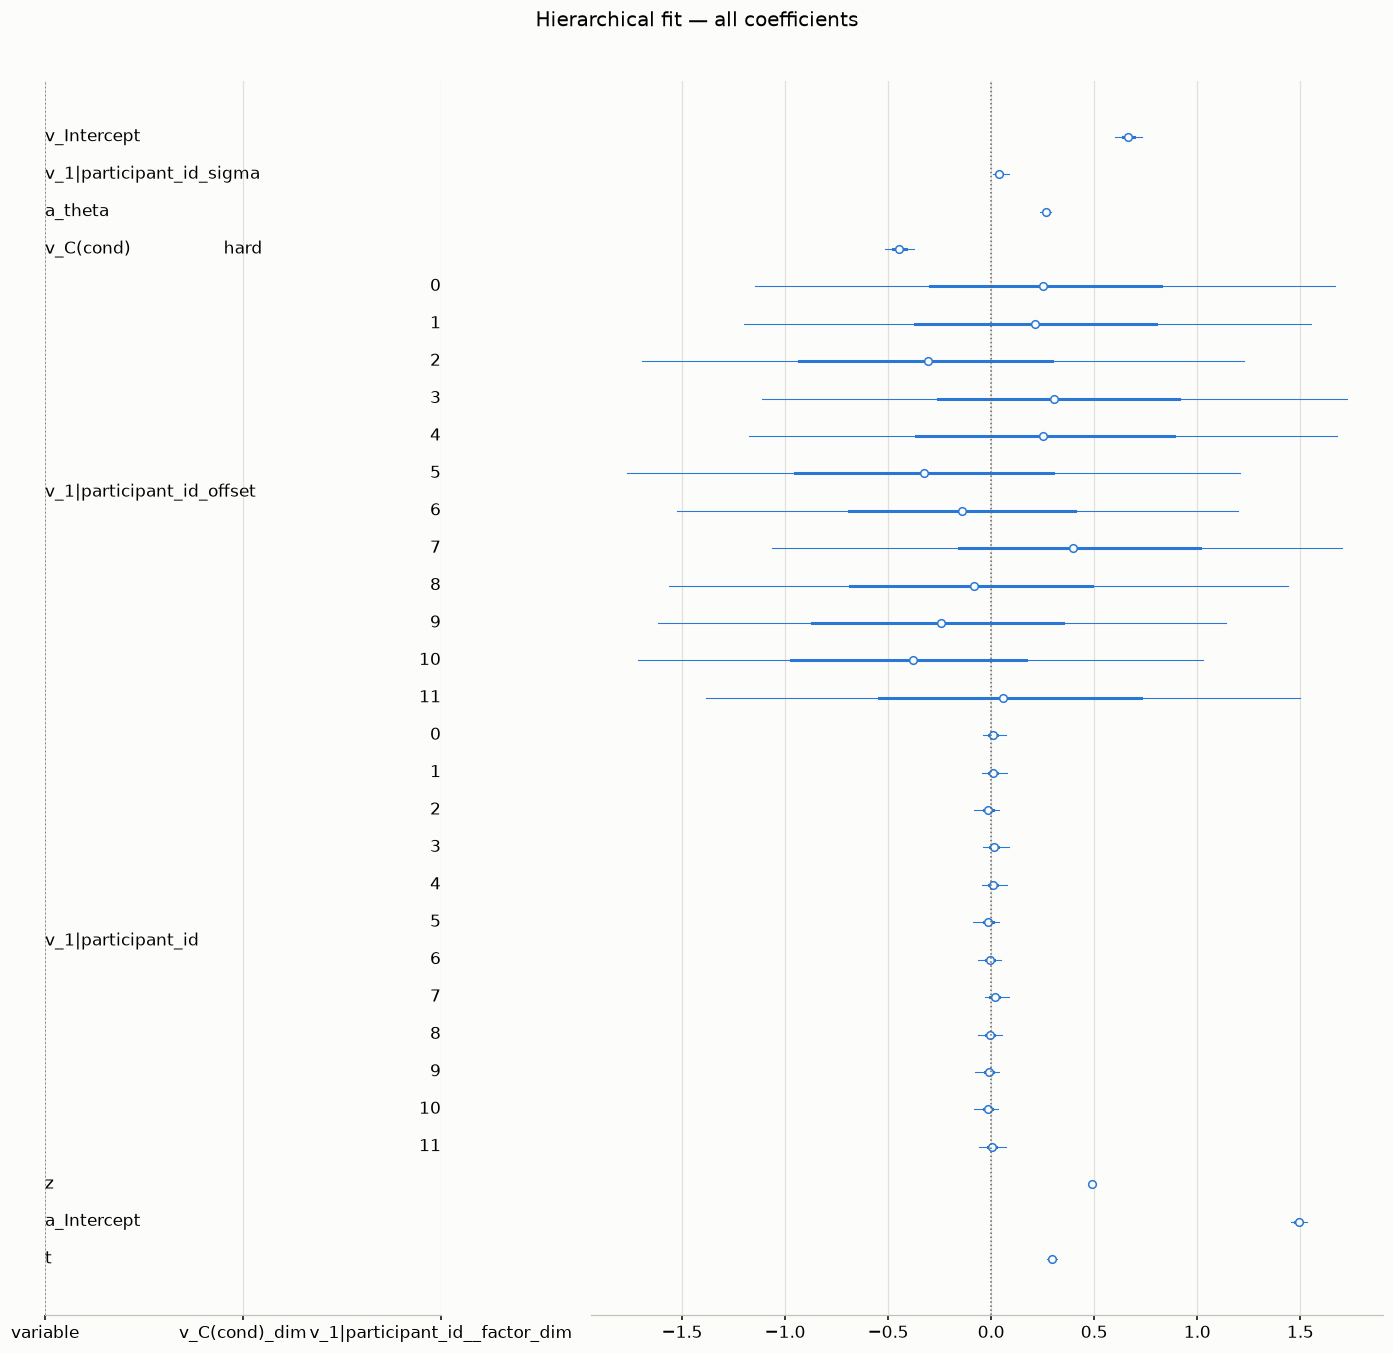

In [18]:
az.plot_forest(model_hier.traces, var_names=coef_vars, combined=True)
fig = plt.gcf()
for ax in fig.axes:                    # a zero line to read "overlaps zero" off
    ax.axvline(0.0, color="0.4", ls=":", lw=1)
fig.suptitle("Hierarchical fit — all coefficients", y=1.01)
fig.tight_layout()

For *this* model the filter drops nothing: HSSM keeps the per-trial parameter
values out of the posterior group and stores only the coefficients. Write the
filter anyway — it costs three lines, and the moment you add a parameter that
HSSM does store per trial, an unfiltered `plot_forest` is a figure with one
row per trial.

## 7. Bring your own likelihood — learned from a simulator

Everything so far used a likelihood HSSM already had. For a model it has never
heard of you supply one, and the contract is small:

> a JAX function `f(data_i, *params) -> scalar`, where `data_i` is one trial's
> `[rt, choice]`. HSSM `vmap`s it over trials and differentiates it for you.

The interesting case is when there is no formula to write down — only a
**simulator**. Then you *learn* the likelihood. We do it for the **plain DDM**
on purpose: HSSM has the exact one, so we can grade the learned likelihood
against the truth — the check you will *not* have in a real application.

### The simulator, and the box it defines

`ssm-simulators` keeps its models in a registry that carries both the
parameter names and their supported ranges. Read them out rather than
hard-coding — those bounds become the region the network is valid in.

In [19]:
import jax.numpy as jnp
from ssms.basic_simulators.simulator import simulator
from ssms.config import model_config
from ssms.hssm_support import get_simulator_fun_internal

SIM_MODEL = "ddm"
_cfg = model_config[SIM_MODEL]
SIM_PARAMS = list(_cfg["params"])
BOX_LO = np.array(_cfg["param_bounds"][0], dtype=float)
BOX_HI = np.array(_cfg["param_bounds"][1], dtype=float)

print(f"{SIM_MODEL}: {SIM_PARAMS}")
for p, lo, hi in zip(SIM_PARAMS, BOX_LO, BOX_HI):
    print(f"  {p}: [{lo:5.2f}, {hi:5.2f}]")

ddm: ['v', 'a', 'z', 't']
  v: [-3.00,  3.00]
  a: [ 0.30,  2.50]
  z: [ 0.10,  0.90]
  t: [ 0.00,  2.00]


Now a dataset at known parameters. Note the **theta-shape rule** from
yesterday's simulation session: a *matrix* of thetas with `n_samples=1` gives
one trial per row, which is exactly the shape a likelihood learner wants.

In [20]:
TRUE_SIM = dict(v=0.9, a=1.3, z=0.5, t=0.3)
N_TRIALS = 1500

_out = simulator(theta=np.tile([TRUE_SIM[p] for p in SIM_PARAMS], (N_TRIALS, 1)),
                 model=SIM_MODEL, n_samples=1, random_state=RANDOM_SEED)
sim_data = pd.DataFrame({"rt": _out["rts"].reshape(-1).astype(float),
                         "response": _out["choices"].reshape(-1).astype(float)})
print(sim_data.head(3).to_string(index=False))
print(f"\n{len(sim_data)} trials   P(+1) = {(sim_data.response > 0).mean():.3f}"
      f"   rt in [{sim_data.rt.min():.2f}, {sim_data.rt.max():.2f}]")

      rt  response
1.032031       1.0
1.428265       1.0
0.816103       1.0

1500 trials   P(+1) = 0.909   rt in [0.42, 7.17]


### Training it

The simulator is fast and vectorized, so we train **online** — a fresh batch
of $(\theta, x)$ pairs at every step, so the network never sees the same draw
twice and there is nothing to overfit.

One detail worth copying. BayesFlow's `make_simulator` wraps your function in a
`LambdaSimulator`, and by default (`is_batched=False`) it calls that function
**once per sample** and stacks the results. Passing `is_batched=True` lets us
hand `ssm-simulators` a whole theta *matrix* per step — the shape rule from
yesterday's session — which is **11x faster** here (2.5 ms vs 27.5 ms per batch
of 128). The published BayesFlow and HSSM examples use the per-trial form.

Training takes about twenty minutes, so the notebook **loads the network
committed to this repository** if it finds one. Set `FORCE_TRAIN = True` to
retrain.

In [21]:
import os
# Must be set BEFORE keras is first imported, and must be jax: the likelihood
# has to be traceable by the sampler. (Nothing above imports keras, so this
# cell is still early enough.)
os.environ["KERAS_BACKEND"] = "jax"

import keras
import bayesflow as bf

FORCE_TRAIN = False
CKPT = pathlib.Path("checkpoints/ddm_nre.keras")

# Sizes follow BayesFlow's own examples/Ratio_Estimation.ipynb, which builds an
# NRE for this very model: a 3x256 MLP, K about half the batch, and a cosine
# decayed learning rate spanning the whole run.
EPOCHS, NUM_BATCHES, BATCH, K = 150, 300, 128, 64


def nre_sample_fn(batch_shape):
    """One fresh simulated trial per theta. x = [log rt, choice]."""
    n = int(np.prod(batch_shape))
    th = rng.uniform(BOX_LO, BOX_HI, size=(n, len(SIM_PARAMS)))
    out = simulator(theta=th, model=SIM_MODEL, n_samples=1,
                    random_state=int(rng.integers(2**31)))
    rt = out["rts"].reshape(-1).astype(np.float64)
    ch = out["choices"].reshape(-1).astype(np.float64)
    return {"theta": th.astype("float32"),
            "x": np.stack([np.log(rt), ch], -1).astype("float32")}


if CKPT.exists() and not FORCE_TRAIN:
    # NOTE: bayesflow must be imported before this, so its @serializable classes
    # are registered — otherwise the load fails with
    # "Could not locate class 'RatioApproximator'".
    approx = keras.saving.load_model(CKPT)
    print(f"loaded trained network from {CKPT}")
else:
    approx = bf.approximators.RatioApproximator(
        inference_network=bf.networks.MLP(widths=(256,) * 3),
        adapter=bf.approximators.RatioApproximator.build_adapter(
            inference_variables=["theta"],     # NRE contrasts THETA...
            inference_conditions=["x"]),       # ...against a fixed x
        standardize=["inference_variables", "inference_conditions"],
        K=K, gamma=1.0)
    approx.compile(optimizer=keras.optimizers.Adam(
        learning_rate=keras.optimizers.schedules.CosineDecay(
            5e-4, decay_steps=EPOCHS * NUM_BATCHES)))
    history = approx.fit(
        simulator=bf.make_simulator(nre_sample_fn, is_batched=True),
        epochs=EPOCHS, num_batches=NUM_BATCHES, batch_size=BATCH, verbose=2)
    bf.diagnostics.plots.loss(history)     # the one diagnostic NRE gets for free
    CKPT.parent.mkdir(parents=True, exist_ok=True)
    approx.save(CKPT)

INFO:bayesflow:Using backend 'jax'


loaded trained network from checkpoints/ddm_nre.keras


### From network to likelihood

The trained ratio is `projector(classifier(...))` applied to the
concatenated, standardized $(\theta, x)$. Written as a JAX function of a
single trial, that is precisely HSSM's `loglik` contract.

Write it as a **factory** that closes over the approximator, rather than as a
function reaching for module globals — that is the shape HSSM's own
`bayesflow_lre_integration.ipynb` tutorial uses, and it means you can hold two
trained networks at once without them colliding.

In [22]:
def make_jax_log_ratio_fn(approximator):
    """Return f(obs_i, *params) -> scalar log-ratio, ready for HSSM."""
    net, proj, std = (approximator.inference_network,
                      approximator.projector,
                      approximator.standardizer)

    def single_trial_log_ratio(data, v, a, z, t):
        theta = jnp.stack([jnp.reshape(p, ()) for p in (v, a, z, t)])
        # same transform the network was trained on
        x = jnp.stack([jnp.log(jnp.maximum(data[0], 1e-6)), data[1]])
        theta = std.maybe_standardize(theta, key="inference_variables")
        x = std.maybe_standardize(x, key="inference_conditions")
        logits = proj(net(jnp.concatenate([theta, x])[None, :]))
        return jnp.squeeze(logits).astype(jnp.float64)

    return single_trial_log_ratio


nre_logp = make_jax_log_ratio_fn(approx)

BayesFlow ships this same function, if you would rather not write it:
`bayesflow.wrappers.pymc.NeuralDistribution(approx, param_names=[...])` exposes
it as `.backend.log_prob`, and wraps it as a `pm.CustomDist` for use in plain
PyMC. We build it by hand here because we want to hand the *function* to HSSM
and let HSSM add the parameter bounds, the non-decision-time guard and the
simulator — see the next cell.

### Registering it

Everything the model *is* — its response columns, its parameters, its
density, its simulator, its validity box — goes in **one call**. After it,
`"ddm_nre"` is a model name like `"ddm"`.

In [23]:
# One call gives HSSM a usable random variable: it adapts the ssms simulator's
# call signature and attaches the three attributes HSSM insists on —
# `model_name`, `choices`, `obs_dim` — reading `choices` straight from the
# ssm-simulators registry. (Build it by hand and forget the attributes and you
# get "ValueError: The simulator function must have a `model_name` attribute.")
nre_rv = get_simulator_fun_internal(SIM_MODEL)
print("rv metadata:", nre_rv.model_name, nre_rv.choices, nre_rv.obs_dim)

hssm.defaults.default_model_config.pop("ddm_nre", None)   # make the cell re-runnable

hssm.register_model(
    name="ddm_nre",
    response=["rt", "response"],
    list_params=SIM_PARAMS,
    choices=[-1, 1],
    description="A DDM whose likelihood was learned from simulations by a "
                "BayesFlow ratio estimator.",
    likelihoods={
        "approx_differentiable": {
            "loglik": nre_logp,
            "backend": "jax",
            "rv": nre_rv,        # <- without this there is no posterior predictive
            # The training box, not a modelling preference. Outside it the
            # network extrapolates and returns confident nonsense.
            "bounds": dict(zip(SIM_PARAMS, zip(BOX_LO.tolist(), BOX_HI.tolist()))),
        }
    },
)

rv metadata: ddm [-1, 1] 2


Declaring the density and the *kind* of density together, in the place that
describes the model, is the point — passing `loglik=` and `loglik_kind=` to
the `HSSM(...)` call splits one fact across two places and lets them disagree.

Now fit it, and fit the analytic DDM on the same data to grade against.

In [24]:
model_nre = hssm.HSSM(data=sim_data, model="ddm_nre", p_outlier=0)
model_nre.sample(sampler="numpyro", draws=500, tune=500, chains=2, cores=1,
                 random_seed=RANDOM_SEED, progressbar=False)

model_exact = hssm.HSSM(data=sim_data, model="ddm", p_outlier=0)
model_exact.sample(sampler="numpyro", draws=500, tune=500, chains=2, cores=1,
                   random_seed=RANDOM_SEED, progressbar=False)

print("LEARNED (NRE)")
print(az.summary(model_nre.traces, var_names=SIM_PARAMS, kind="stats").to_string())
print("\nEXACT (analytic WFPT)")
print(az.summary(model_exact.traces, var_names=SIM_PARAMS, kind="stats").to_string())
print("\nTRUE:", TRUE_SIM)

Model initialized successfully.


INFO:hssm:Model initialized successfully.


Using default initvals. 



INFO:hssm:Using default initvals. 



NUTS[numpyro]: [a, z, t, v]


...

NUTS[numpyro]: [a, z, t, v]


INFO:pymc.sampling.mcmc:NUTS[numpyro]: [a, z, t, v]


We recommend running at least 4 chains for robust computation of convergence diagnostics


INFO:pymc.stats.convergence:We recommend running at least 4 chains for robust computation of convergence diagnostics


LEARNED (NRE)
   mean     sd eti89_lb eti89_ub
v   0.8  0.031     0.75     0.85
a   1.3  0.017      1.2      1.3
z   0.5  0.011     0.49     0.52
t  0.31  0.012     0.29     0.33

EXACT (analytic WFPT)
   mean     sd eti89_lb eti89_ub
v  0.88  0.033     0.83     0.93
a   1.3  0.021      1.3      1.3
z   0.5  0.011     0.48     0.52
t   0.3  0.012     0.28     0.31

TRUE: {'v': 0.9, 'a': 1.3, 'z': 0.5, 't': 0.3}


<details class="sbi-warn" open>
<summary>⚠️ <b><code>p_outlier</code> must be 0 with a ratio estimator</b></summary>

HSSM's lapse process mixes the likelihood with a uniform density:
$(1-p)\,\mathcal{L} + p\,\mathcal{U}$. That addition needs $\mathcal{L}$ on a
genuine probability scale, and a ratio is only defined up to the factor
$p(x)$ — so the mixture weights the two terms wrongly, silently, because
nothing about the arithmetic fails.

The same rules out anything else reading the likelihood as an absolute
quantity: `az.loo`, `az.waic`, and Bayes factors across separately-trained
networks.

</details>

Read the two summaries together and note **both** things. The interval
*widths* agree with the exact fit — the learned likelihood is not pretending
to know more than the data support, which is the failure mode to fear. But
`v` carries a small bias beyond the exact fit's own. That is the trade: a
likelihood for a model you could only simulate, at the cost of a bias you can
measure but not remove.

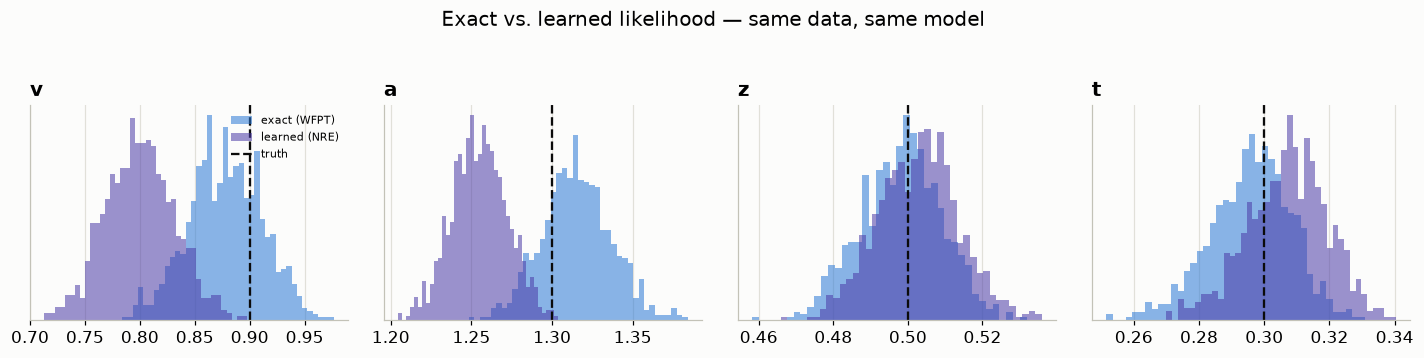

In [25]:
fig, axes = plt.subplots(1, 4, figsize=(13, 3.1))
for ax, p in zip(axes, SIM_PARAMS):
    for tr, colour, lbl in [(model_exact.traces, S.PRIMARY, "exact (WFPT)"),
                            (model_nre.traces, S.NAIVE, "learned (NRE)")]:
        ax.hist(tr.posterior[p].values.ravel(), bins=40, density=True,
                color=colour, alpha=0.55, label=lbl)
    S.truth_line(ax, TRUE_SIM[p], axis="x")
    ax.set(title=p, yticks=[])
axes[0].legend(fontsize=7)
fig.suptitle("Exact vs. learned likelihood — same data, same model", y=1.04)
fig.tight_layout()

### Did the sampler behave?

Same checks as for any other model — a learned likelihood buys no exemption.

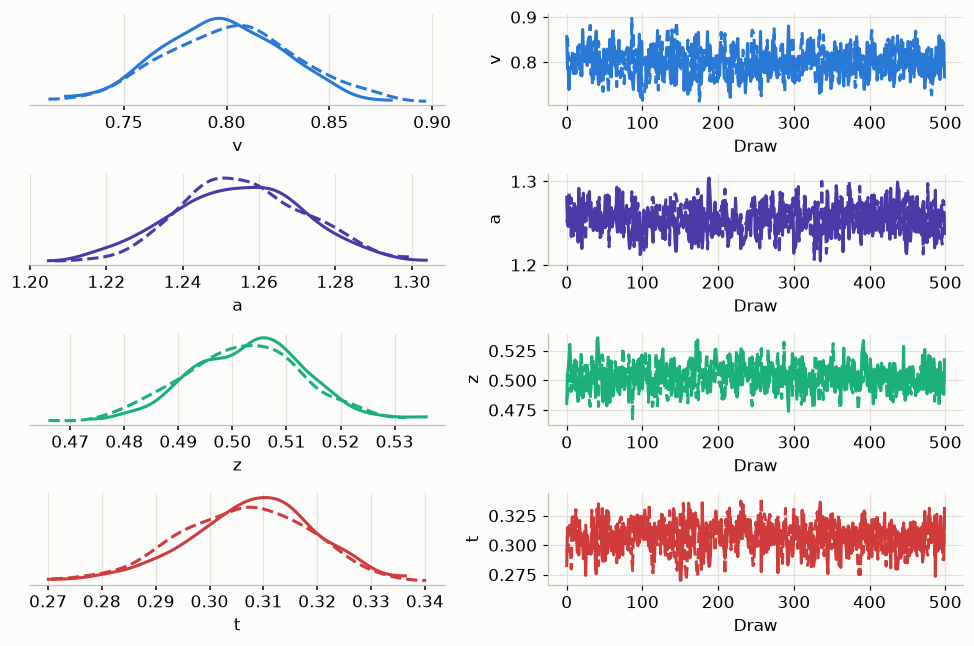

In [26]:
az.plot_trace_dist(model_nre.traces, var_names=SIM_PARAMS, combined=False)
plt.gcf().set_size_inches(9, 6)
plt.tight_layout()

And the pair plot, which is where a custom likelihood usually confesses.
Divergences are drawn on top: if they pile up in one region rather than
scattering, the geometry there is the problem, not the sampler.

divergences — learned: 0   exact: 0


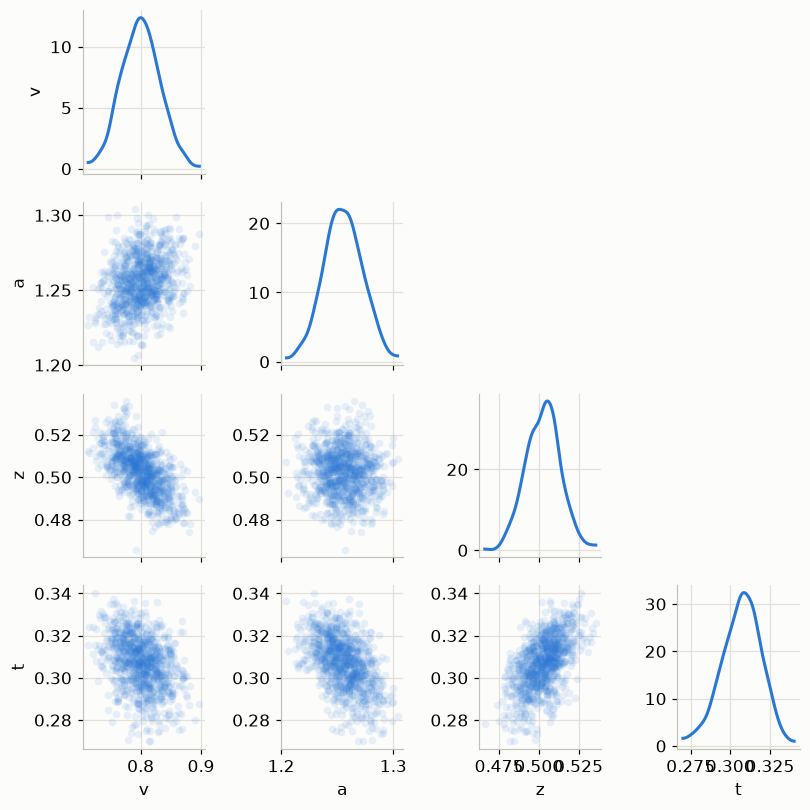

In [27]:
# ArviZ 1.x styles sub-plots through `visuals`, and divergences are OFF by
# default — you have to ask for them.
az.plot_pair(model_nre.traces, var_names=SIM_PARAMS,
             marginal=True, marginal_kind="kde",
             visuals={"divergence": True, "scatter": {"alpha": 0.1}})
plt.gcf().set_size_inches(7.5, 7.5)
plt.tight_layout()

print("divergences — learned:",
      int(model_nre.traces.sample_stats["diverging"].values.sum()),
      "  exact:", int(model_exact.traces.sample_stats["diverging"].values.sum()))

### Posterior predictive

Because the registry entry carries `rv=`, the learned model can **simulate**
as well as score — so HSSM's own plots work on it, unchanged. Note we never
call `sample_posterior_predictive`: the plot generates the draws it needs.

No posterior_predictive samples found. Generating posterior_predictive samples using the provided DataTree object and the original data. This will modify the provided DataTree object, or if not provided, the traces object stored inside the model.


INFO:hssm:No posterior_predictive samples found. Generating posterior_predictive samples using the provided DataTree object and the original data. This will modify the provided DataTree object, or if not provided, the traces object stored inside the model.


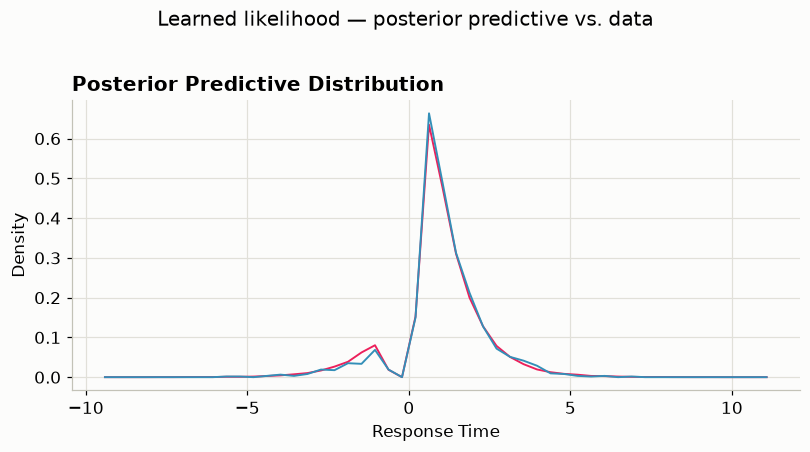

In [28]:
model_nre.plot_predictive()
plt.gcf().set_size_inches(7.5, 4)
plt.gcf().suptitle("Learned likelihood — posterior predictive vs. data", y=1.02)
plt.tight_layout()

That is the whole point of registering the model properly rather than keeping
the network in a variable: the likelihood is learned, but everything
downstream — bounds, the lapse process, predictive sampling, the plots — is
the same machinery a built-in model gets.

<details class="sbi-note">
<summary>▶️ <b>Which HSSM plots work for a registered custom model</b></summary>

`plot_predictive` and `plot_quantile_probability` are data-driven: they need
the observed data and a posterior predictive, so they work for any registered
model with an `rv`. (The quantile probability plot additionally needs a
**condition column** to split on, which this flat single-θ dataset does not
have — see section 4 for it on the conditioned dataset.)

`plot_model_cartoon` is the exception. It draws the latent trajectory by
calling `ssms.basic_simulators.simulator(model=model.model_name, …)`, passing
the *HSSM* model name straight through. Our name — `"ddm_nre"` — means nothing
to `ssm-simulators`, so the cartoon only works when you register under a name
that package already knows.

</details>

<details class="sbi-tip">
<summary>💡 <b>When you need a portable artifact instead</b></summary>

The route above hands HSSM a **JAX callable**, which needs nothing installed
beyond what we already have — but it also means the likelihood only exists
inside this Python session.

For an artifact you can ship, `lanfactory.onnx.transform_bayesflow_to_onnx`
exports a trained approximator to ONNX, and HSSM then takes the file path
directly: `hssm.HSSM(..., loglik="my_net.onnx",
loglik_kind="approx_differentiable")`. It has real constraints — export needs
`KERAS_BACKEND="torch"`, and the network must use an identity adapter — so see
HSSM's `bayesflow_nle_onnx_integration.ipynb` tutorial before reaching for it.

</details>

### Quick reference

| want to | call |
|---|---|
| a model | `hssm.HSSM(data=df, model="ddm")` |
| check what you built | `print(model)` · `model.graph()` |
| a regression on a parameter | `include=[{"name": "v", "formula": "v ~ 1 + x"}]` |
| participant effects | `"v ~ 1 + x + (1\|participant_id)"`, `noncentered=True` |
| no lapse process | `p_outlier=None` |
| summarise | `az.summary(model.traces, var_names=[...])` |
| SSM fit check | `model.plot_quantile_probability(cond=..., predictive_style="ellipse")` |
| see the process | `hssm.plotting.plot_model_cartoon(model)` |
| known-truth data | `model.sample_do({...}, draws=1)` |
| a simulator's parameters and bounds | `ssms.config.model_config["ddm"]` |
| one trial per parameter row | `simulator(theta=<matrix>, model="ddm", n_samples=1)` |
| your own likelihood | `hssm.register_model(name=..., likelihoods={"approx_differentiable": {"loglik": <jax fn>, "backend": "jax", "rv": <sim>, "bounds": ...}})` |
| learn one from simulations | `bf.approximators.RatioApproximator` (NRE) |

**Next, at 11:00:** the `sigma` in `(1|participant_id)` has a posterior
geometry that will break your sampler if you let it.